In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import kdeplot
from ot.lp import wasserstein_1d as wd
from scipy.stats import t
from triangular_transport.flows.methods.sampling import inf_train_gen

plt.style.use("ggplot")

In [2]:
mcmc_mod = np.load("mcmc_mod_results/avg_wd_mcmc.npy")
mcmc_prior_init = np.load("mcmc_prior_init_results/avg_wd_mcmc.npy")
mcmc_norm = np.load("mcmc_norm_results/avg_wd_mcmc.npy")
mcmc_rare = np.load("mcmc_rare_results/avg_wd_mcmc.npy")
mcmc_mod_std = np.load("mcmc_mod_results/std_wd_mcmc.npy")
mcmc_rare_std = np.load("mcmc_rare_results/std_wd_mcmc.npy")
mcmc_norm_std = np.load("mcmc_norm_results/std_wd_mcmc.npy")
sample_no_list = np.load("mcmc_mod_results/sample_no_list.npy")

eval_no_array = np.load("init_data/eval_no_array.npy")
nevals_norm = eval_no_array[0].item()
nevals_mod = eval_no_array[1].item()
nevals_rare = eval_no_array[2].item()

In [3]:
eval_no_array

array([84, 46, 68], dtype=int32)

In [4]:
sample_no_list

array([     2,      4,      8,     16,     32,     64,    128,    256,
          512,   1024,   2048,   4096,   8192,  16384,  20000,  30000,
        40000,  50000,  60000,  70000,  80000,  90000, 100000])

In [5]:
no_trials = 10
ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_trig_1_regimes/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_norm = np.mean(ode_array_1, axis=0)
ode_norm_std = np.std(ode_array_1, axis=0)

ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_trig_2_regimes/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mod = np.mean(ode_array_1, axis=0)
ode_mod_std = np.std(ode_array_1, axis=0)

ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_trig_3_regimes/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_rare = np.mean(ode_array_1, axis=0)
ode_rare_std = np.std(ode_array_1, axis=0)

In [6]:
map_norm = np.linspace(1, mcmc_norm[0], num=len(sample_no_list[0:6]))
map_mod = np.linspace(1, mcmc_mod[0], num=len(sample_no_list[0:6]))
map_rare = np.linspace(1, mcmc_rare[0], num=len(sample_no_list[0:6]))

In [7]:
mcmc_prior_init

array([0.50862846, 0.50899499, 0.50953425, 0.50921224, 0.5067496 ,
       0.50740708, 0.51787732, 0.60975212, 0.77150655, 0.805102  ,
       0.64764335, 0.46797313, 0.31748444, 0.20575464, 0.1817959 ,
       0.14153544, 0.11888366, 0.10301562, 0.09215728, 0.08350603,
       0.07680913, 0.07138063, 0.06669276])

In [8]:
xs = np.linspace(1, 100000, num=100000)
mc_rate = 1 / np.sqrt(xs)

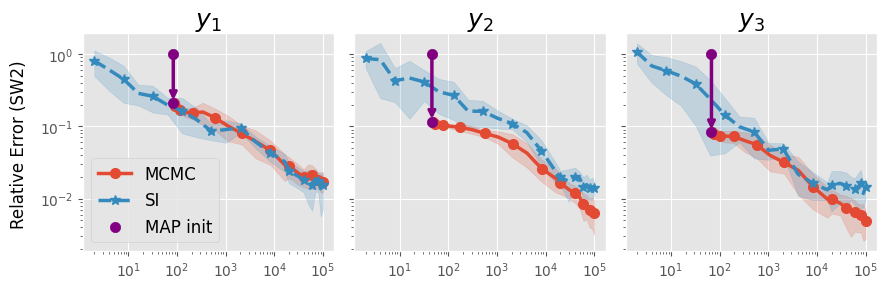

In [53]:
prior_error = 1.0  # error at 2 samples from prior-init chain, proxy for "starting at the prior"

fig, ax = plt.subplots(1, 3, figsize=(9.0, 3.0), sharey=True)

# --- norm (y=0) ---
lw = 2.5
ms = 7.0
im0_1 = ax[0].plot(sample_no_list + nevals_norm, mcmc_norm, marker="o", markevery=2, linewidth=lw, markersize=ms, label="MCMC")
im0_2 = ax[0].plot(sample_no_list, ode_norm, marker="*", linestyle="dashed", linewidth=lw, markersize=ms, markevery=2, label="SI")
# ax[0].plot(xs, mc_rate, linestyle="dashdot", marker="^", markevery=20000, linewidth=lw, markersize=ms)
ax[0].fill_between(
    sample_no_list + nevals_norm,
    mcmc_norm - mcmc_norm_std,
    mcmc_norm + mcmc_norm_std,
    color=im0_1[0].get_color(),
    alpha=0.2
)
ax[0].fill_between(
    sample_no_list,
    ode_norm - ode_norm_std,
    ode_norm + ode_norm_std,
    color=im0_2[0].get_color(),
    alpha=0.2
)
ax[0].annotate("",
    xy=(nevals_norm, mcmc_norm[0]),
    xytext=(nevals_norm, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2.5))
ax[0].scatter([nevals_norm], [prior_error], color="purple", zorder=5, s=55)
ax[0].scatter([nevals_norm], [mcmc_norm[0]], color="purple", zorder=5, s=55, label="MAP init")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_1$", fontsize=18, pad=4)
ax[0].legend(fontsize=12)

# --- mod (y=-1) ---
im1_1 = ax[1].plot(sample_no_list + nevals_mod, mcmc_mod, marker="o", markevery=2, linewidth=lw, markersize=ms)
im1_2 = ax[1].plot(sample_no_list, ode_mod, marker="*", linestyle="dashed", linewidth=lw, markersize=ms, markevery=2)
# ax[1].plot(xs, mc_rate)
ax[1].fill_between(
    sample_no_list + nevals_mod,
    mcmc_mod - mcmc_mod_std,
    mcmc_mod + mcmc_mod_std,
    color=im1_1[0].get_color(),
    alpha=0.2
)
ax[1].fill_between(
    sample_no_list,
    ode_mod - ode_mod_std,
    ode_mod + ode_mod_std,
    color=im1_2[0].get_color(),
    alpha=0.2
)
ax[1].annotate("",
    xy=(nevals_mod, mcmc_mod[0]),
    xytext=(nevals_mod, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2.5))
ax[1].scatter([nevals_mod], [prior_error], color="purple", zorder=5, s=55)
ax[1].scatter([nevals_mod], [mcmc_mod[0]], color="purple", zorder=5, s=55)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=18, pad=4)

# --- rare (y=-4.2) ---
im2_1 = ax[2].plot(sample_no_list + nevals_rare, mcmc_rare, marker="o", markevery=2, linewidth=lw, markersize=ms)
im2_2 = ax[2].plot(sample_no_list, ode_rare, marker="*", linestyle="dashed", linewidth=lw, markersize=ms, markevery=2)
# ax[2].plot(xs, mc_rate)
ax[2].fill_between(
    sample_no_list + nevals_rare,
    mcmc_rare - mcmc_rare_std,
    mcmc_rare + mcmc_rare_std,
    color=im2_1[0].get_color(),
    alpha=0.2
)
ax[2].fill_between(
    sample_no_list,
    ode_rare - ode_rare_std,
    ode_rare + ode_rare_std,
    color=im2_2[0].get_color(),
    alpha=0.2
)
ax[2].annotate("",
    xy=(nevals_rare, mcmc_rare[0]),
    xytext=(nevals_rare, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2.5))
ax[2].scatter([nevals_rare], [prior_error], color="purple", zorder=5, s=55)
ax[2].scatter([nevals_rare], [mcmc_rare[0]], color="purple", zorder=5, s=55)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_3$", fontsize=18, pad=4)

fig.supylabel("Relative Error (SW2)")
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     loc="upper left",
#     ncol=2,
#     frameon=False,
#     fontsize=10,
#     handlelength=1.4,
#     handletextpad=0.4,
#     columnspacing=0.8,
#     labelspacing=0.3,
#     borderaxespad=0.2,
# )
plt.tight_layout()
plt.savefig("images/lv-conv.png", dpi=300)

In [10]:
import pickle

In [11]:
with open(f"hyperparam_results/best_hyperparams_low.pkl", "rb") as f:
    hyperparams = pickle.load(f)

with open(f"hyperparam_results/best_hyperparams_mid.pkl", "rb") as f:
    hyperparams_mid = pickle.load(f)

with open(f"hyperparam_results/best_hyperparams_high.pkl", "rb") as f:
    hyperparams_high = pickle.load(f)

In [12]:
hyperparams

{'hidden_layer': 411,
 'num_hidden_layers': 2,
 'peak_value': 0.009212001776,
 'weight_decay': 1.0572368e-06,
 'interpolant': 'trig_interpolant'}

In [13]:
hyperparams_mid

{'hidden_layer': 217,
 'num_hidden_layers': 3,
 'peak_value': 0.0079707539788,
 'weight_decay': 0.0006560675054,
 'interpolant': 'trig_interpolant'}

In [14]:
hyperparams_high

{'hidden_layer': 441,
 'num_hidden_layers': 5,
 'peak_value': 0.0005794886939,
 'weight_decay': 2.45540793e-05,
 'interpolant': 'trig_interpolant'}

In [15]:
np.load("hyperparam_results/incumbent_loss_low.npy")

array([0.06572603])

In [16]:
np.load("hyperparam_results/incumbent_loss_mid.npy")

array([0.0525057])

In [17]:
np.load("hyperparam_results/incumbent_loss_high.npy")

array([0.01087738])